In [3]:
!wget https://www.dropbox.com/scl/fi/t9zeok6etatdpxsp54xih/SiblingsDB.zip?rlkey=fluq21wjavok4jn849v09lgmu&e=1&dl=0

--2025-01-19 00:18:43--  https://www.dropbox.com/scl/fi/t9zeok6etatdpxsp54xih/SiblingsDB.zip?rlkey=fluq21wjavok4jn849v09lgmu
Resolving www.dropbox.com (www.dropbox.com)... 162.125.85.18, 2620:100:6031:18::a27d:5112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.85.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc4fc63e6cb0e446483f99f7d63c.dl-eu.dropboxusercontent.com/cd/0/inline/Cif0GrRH2HHsXz5aE2ybIvO_nKtjOglYP_7PmtkAiBQgA_XX0E6Eaw_Mu-VZwZv4b10ZqINk3YkuL8-YkbAYI3_SIFGA7wojbmnZIE_7sG5E_lSP8P4AYZsiN9uhwa-gZLi4Cvaixxsw9-b2evbmVZ5K/file# [following]
--2025-01-19 00:18:44--  https://uc4fc63e6cb0e446483f99f7d63c.dl-eu.dropboxusercontent.com/cd/0/inline/Cif0GrRH2HHsXz5aE2ybIvO_nKtjOglYP_7PmtkAiBQgA_XX0E6Eaw_Mu-VZwZv4b10ZqINk3YkuL8-YkbAYI3_SIFGA7wojbmnZIE_7sG5E_lSP8P4AYZsiN9uhwa-gZLi4Cvaixxsw9-b2evbmVZ5K/file
Resolving uc4fc63e6cb0e446483f99f7d63c.dl-eu.dropboxusercontent.com (uc4fc63e6cb0e446483f99f7d63c.dl-eu.dropboxusercontent.com)... 162

In [ ]:
! unzip /content/SiblingsDB.zip?rlkey=fluq21wjavok4jn849v09lgmu -d /content/SiblingsDB

Archive:  /content/SiblingsDB.zip?rlkey=fluq21wjavok4jn849v09lgmu
   creating: /content/SiblingsDB/DBs/
   creating: /content/SiblingsDB/DBs/HQf/
   creating: /content/SiblingsDB/DBs/HQfp/
   creating: /content/SiblingsDB/DBs/HQfps/
   creating: /content/SiblingsDB/DBs/HQfps/100/
 extracting: /content/SiblingsDB/DBs/HQfps/100/_DSC0152.csv  
 extracting: /content/SiblingsDB/DBs/HQfps/100/_DSC0152.jpg  
 extracting: /content/SiblingsDB/DBs/HQfps/100/_DSC0154.csv  
 extracting: /content/SiblingsDB/DBs/HQfps/100/_DSC0154.jpg  
 extracting: /content/SiblingsDB/DBs/HQfps/100/_DSC0156.csv  
 extracting: /content/SiblingsDB/DBs/HQfps/100/_DSC0156.jpg  
 extracting: /content/SiblingsDB/DBs/HQfps/100/_DSC0159.csv  
 extracting: /content/SiblingsDB/DBs/HQfps/100/_DSC0159.jpg  
   creating: /content/SiblingsDB/DBs/HQfps/104/
 extracting: /content/SiblingsDB/DBs/HQfps/104/_DSC0181.csv  
 extracting: /content/SiblingsDB/DBs/HQfps/104/_DSC0181.jpg  
 extracting: /content/SiblingsDB/DBs/HQfps/104/_DSC

In [4]:
import pandas as pd

HQf = pd.read_csv('/content/SiblingsDB/HQf.csv')
HQf

,unique couple ID,are they siblings?,# votes,Yes' answers,No' answers,first picture,second picture
0,0003_0001,1,443,250,193,3/DSC5751,1/DSC5755_1
1,0005_0001,-1,443,55,388,5/DSC5763,1/DSC5755_1
2,0006_0003,-1,444,36,408,6/DSC5760,3/DSC5751
3,0006_0005,1,444,232,212,6/DSC5760,5/DSC5763
4,0008_0007,1,443,141,302,8/DSC5774,7/DSC5769
...,...,...,...,...,...,...,...
199,0267_0266,1,444,155,289,267/DSC3077,266/DSC3067
200,0268_0260,-1,443,124,319,268/DSC3088,260_260
201,0268_0261,-1,444,119,325,268/DSC3088,261_261
202,0268_0266,1,444,197,247,268/DSC3088,266/DSC3067


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
%ls "/content/drive/MyDrive/Genotek kinship recognition/Existing dataset exploration_preparation/files"

FIW_buffalo_sc_faces_info.pkl          KinFaceW-II_pairs.csv
KinFaceW-I_buffalo_sc_faces_info.pkl   KinFaceW-I_pairs.csv
KinFaceW-I_faces_info.pkl              SiblingsDB_buffalo_sc_faces_info.pkl
KinFaceW-II_buffalo_sc_faces_info.pkl  SiblingsDB_faces_info.pkl
KinFaceW-II_faces_info.pkl


In [8]:
import pickle

with open("/content/drive/MyDrive/Genotek kinship recognition/Existing dataset exploration_preparation/files/SiblingsDB_buffalo_sc_faces_info.pkl", "rb") as f:
  buffalo_sc_embeddings = pickle.load(f)
with open("/content/drive/MyDrive/Genotek kinship recognition/Existing dataset exploration_preparation/files/SiblingsDB_faces_info.pkl", "rb") as f:
  buffalo_l_embeddings = pickle.load(f)

In [15]:
list(buffalo_sc_embeddings.keys())[:5]

['SiblingsDB/DBs/HQf/221/_DSC2256.jpg',
 'SiblingsDB/DBs/HQf/194/_DSC0812.jpg',
 'SiblingsDB/DBs/HQf/90/_DSC0091.jpg',
 'SiblingsDB/DBs/HQf/19/_DSC5859.jpg',
 'SiblingsDB/DBs/HQf/52/_DSC5979.jpg']

In [34]:
from scipy.spatial.distance import cosine

def get_distance(image1, image2, embeddings, prefix):
    image1 = prefix + image1 + ".jpg"
    if "_DSC" in image1:
      image1 = image1[:image1.rfind("_")] + "/" + image1[image1.rfind("_")+1:]
    elif "DSC" in image1:
      image1 = image1[:image1.rfind("/")+1] + "_" + image1[image1.rfind("/")+1:]
    else:
      image1 = image1.replace("_", "/")
    image2 = prefix + image2 + ".jpg"
    if "_DSC" in image2:
      image2 = image2[:image2.rfind("_")] + "/" + image2[image2.rfind("_")+1:]
    elif "DSC" in image2:
      image2 = image2[:image2.rfind("/")+1] + "_" + image2[image2.rfind("/")+1:]
    else:
      image2 = image2.replace("_", "/")
    if embeddings[image1] is None or embeddings[image2] is None:
        return None
    return cosine(embeddings[image1]["embedding"], embeddings[image2]["embedding"])


HQf["buffalo_l_cosine_distance"] = HQf.apply(lambda x: get_distance(x["first picture"], x["second picture"], buffalo_l_embeddings, "SiblingsDB/DBs/HQf/"), axis=1)
HQf["buffalo_sc_cosine_distance"] = HQf.apply(lambda x: get_distance(x["first picture"], x["second picture"], buffalo_sc_embeddings, "SiblingsDB/DBs/HQf/"), axis=1)
HQf

,unique couple ID,are they siblings?,# votes,Yes' answers,No' answers,first picture,second picture,buffalo_l_cosine_distance,buffalo_sc_cosine_distance
0,0003_0001,1,443,250,193,3/DSC5751,1/DSC5755_1,0.842240,0.736955
1,0005_0001,-1,443,55,388,5/DSC5763,1/DSC5755_1,0.909332,0.827822
2,0006_0003,-1,444,36,408,6/DSC5760,3/DSC5751,0.846054,0.842959
3,0006_0005,1,444,232,212,6/DSC5760,5/DSC5763,0.759032,0.729403
4,0008_0007,1,443,141,302,8/DSC5774,7/DSC5769,0.932295,0.915050
...,...,...,...,...,...,...,...,...,...
199,0267_0266,1,444,155,289,267/DSC3077,266/DSC3067,0.586867,0.667694
200,0268_0260,-1,443,124,319,268/DSC3088,260_260,0.953275,0.857631
201,0268_0261,-1,444,119,325,268/DSC3088,261_261,1.092113,0.973531
202,0268_0266,1,444,197,247,268/DSC3088,266/DSC3067,0.721227,0.679659


In [35]:
HQf["buffalo_l_cosine_distance"].isna().sum(), HQf["buffalo_sc_cosine_distance"].isna().sum()

(4, 4)

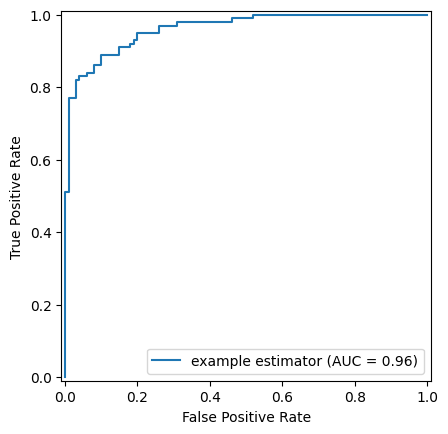

In [44]:
from sklearn import metrics

df_non_empty = HQf[HQf["buffalo_l_cosine_distance"].notna()]
y = df_non_empty['are they siblings?']
pred = -df_non_empty["buffalo_l_cosine_distance"]


fpr, tpr, thresholds = metrics.roc_curve(y, pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='example estimator')
display.plot()

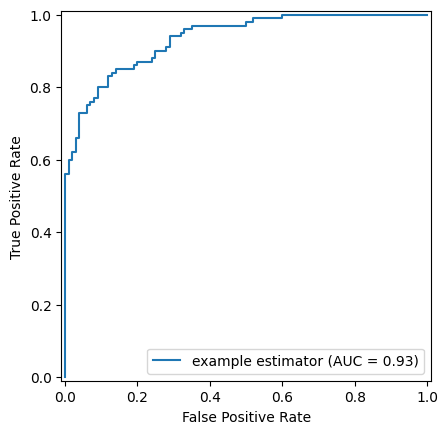

In [45]:
from sklearn import metrics

df_non_empty = HQf[HQf["buffalo_sc_cosine_distance"].notna()]
y = df_non_empty['are they siblings?']
pred = -df_non_empty["buffalo_sc_cosine_distance"]


fpr, tpr, thresholds = metrics.roc_curve(y, pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='example estimator')
display.plot()

In [64]:
HQf["are they siblings?"] = HQf["are they siblings?"].replace({-1: 0})

In [67]:
from sklearn.metrics import roc_curve
import numpy as np


def get_matrix_values(y_score, y_true):
    ###
    # Compute the TPR and FPR for different thresholds
    ###
    fpr, tpr, thresholds = roc_curve(y_true, y_score)

    ###
    # Calculate the number of positive and negative samples
    ###
    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)

    ###
    # Compute TP, TN, FP, and FN for each threshold
    ###
    tps = tpr * P
    tns = (1 - fpr) * N
    fps = fpr * N
    fns = P - tps



    return tps, fps, tns, fns, thresholds #if score >= threshold, we assign the class 1


def get_accuracy_curve(y_score, y_true):
    tps, fps, tns, fns, thresholds = get_matrix_values(y_score, y_true)
    accuracy = (tps + tns) / (tps + tns + fns + fps)
    return accuracy, thresholds

In [74]:
from sklearn.metrics import roc_curve
import numpy as np


def get_matrix_values(y_score, y_true):
    ###
    # Compute the TPR and FPR for different thresholds
    ###
    fpr, tpr, thresholds = roc_curve(y_true, y_score)

    ###
    # Calculate the number of positive and negative samples
    ###
    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)

    ###
    # Compute TP, TN, FP, and FN for each threshold
    ###
    tps = tpr * P
    tns = (1 - fpr) * N
    fps = fpr * N
    fns = P - tps



    return tps, fps, tns, fns, thresholds #if score >= threshold, we assign the class 1


def get_accuracy_curve(y_score, y_true):
    tps, fps, tns, fns, thresholds = get_matrix_values(y_score, y_true)
    accuracy = (tps + tns) / (tps + tns + fns + fps)
    return accuracy, thresholds


def cross_validation(df, distance_column):
  accuracy_list = []
  df["fold"] = np.random.randint(1, 6, len(df))
  for fold in df["fold"].unique():
    train_df = df[df["fold"] != fold].copy()
    test_df = df[df["fold"] == fold].copy()
    median_value = train_df[distance_column].median()
    train_df[distance_column] = train_df[distance_column].fillna(median_value)
    test_df[distance_column] = test_df[distance_column].fillna(median_value)

    y_train = train_df['are they siblings?']
    y_score = np.array(train_df[distance_column])

    accuracies, thresholds = get_accuracy_curve(-y_score, np.array(y_train))

    best_accuracy = max(accuracies)
    best_threshold = -max(zip(accuracies, thresholds), key = lambda x: x[0])[1]

    print(f"Fold {fold} best train accuracy: {best_accuracy}, best threshold: {best_threshold}")

    y_test = test_df['are they siblings?']
    y_score = np.array(test_df[distance_column])
    y_pred = np.array(y_score < best_threshold, dtype=int)
    accuracy = metrics.accuracy_score(y_test, y_pred)
    accuracy_list.append(accuracy)
    print(f"Fold {fold} test accuracy: {accuracy}")

  return np.mean(accuracy_list)

In [75]:
cross_validation(HQf, "buffalo_l_cosine_distance")

Fold 3 best train accuracy: 0.906832298136646, best threshold: 0.8602392577204502
Fold 3 test accuracy: 0.813953488372093
Fold 5 best train accuracy: 0.8975903614457831, best threshold: 0.849741303873922
Fold 5 test accuracy: 0.8421052631578947
Fold 1 best train accuracy: 0.8924050632911392, best threshold: 0.849741303873922
Fold 1 test accuracy: 0.8695652173913043
Fold 4 best train accuracy: 0.8809523809523809, best threshold: 0.8422404375652398
Fold 4 test accuracy: 0.8333333333333334
Fold 2 best train accuracy: 0.8834355828220859, best threshold: 0.8986057938098936
Fold 2 test accuracy: 0.9024390243902439


0.8522792653289739

In [76]:
cross_validation(HQf, "buffalo_sc_cosine_distance")

Fold 1 best train accuracy: 0.8205128205128205, best threshold: 0.8473338285812612
Fold 1 test accuracy: 0.9375
Fold 2 best train accuracy: 0.8616352201257862, best threshold: 0.8422600495793703
Fold 2 test accuracy: 0.7555555555555555
Fold 4 best train accuracy: 0.874251497005988, best threshold: 0.8637837100477095
Fold 4 test accuracy: 0.7297297297297297
Fold 3 best train accuracy: 0.8614457831325302, best threshold: 0.8242763933820583
Fold 3 test accuracy: 0.7368421052631579
Fold 5 best train accuracy: 0.8392857142857143, best threshold: 0.8707122963607379
Fold 5 test accuracy: 0.8888888888888888


0.8097032558874664